Fetching AI4I 2020 Predictive Maintenance Dataset from UCI...
Engineering Physics-Based Features...

Generating Pre-Modeling Data Visualizations (EDA)...


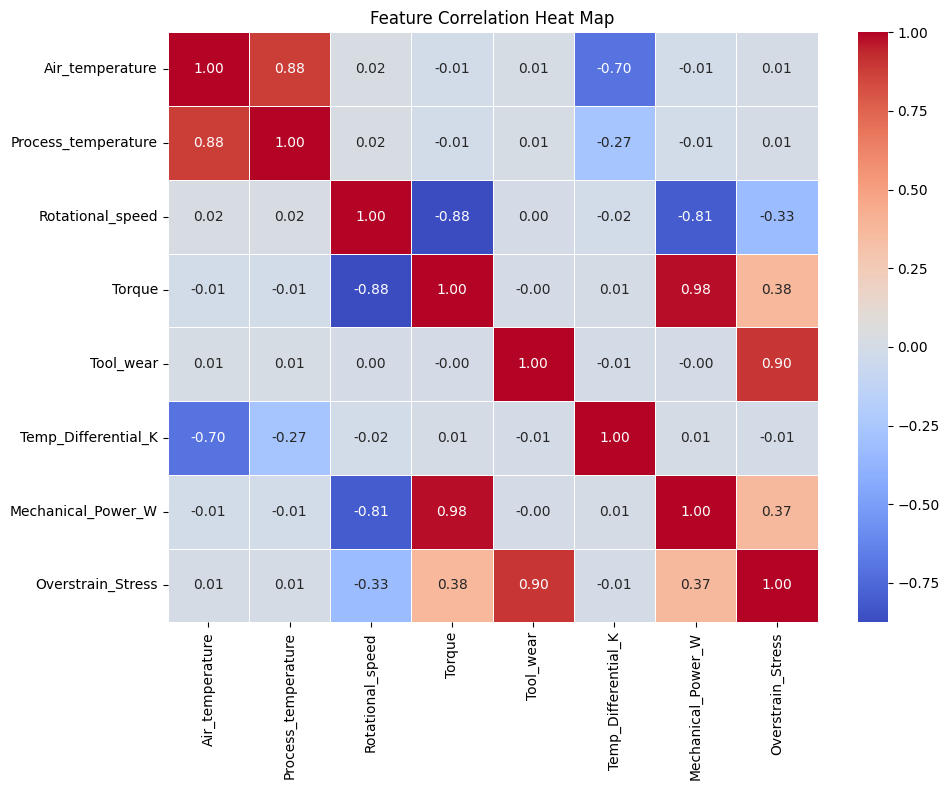

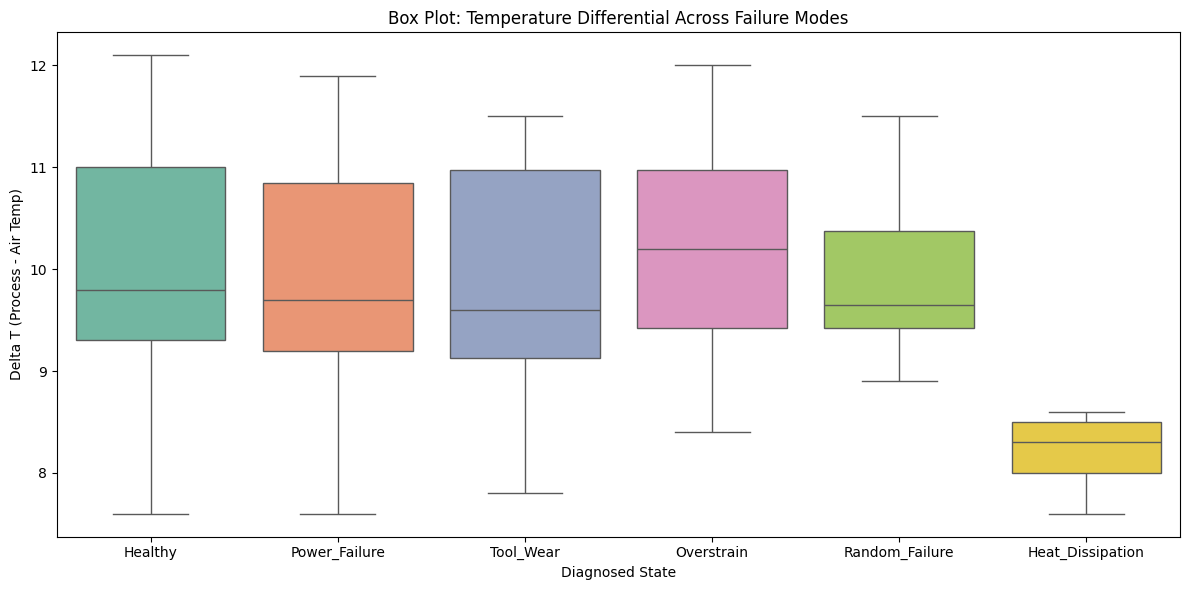


Preparing and balancing data for the AI...
Dataset successfully split! Training records: 8000 | Testing records: 2000
Fetching AI4I 2020 Predictive Maintenance Dataset from UCI...
Engineering Physics-Based Features...

Generating Pre-Modeling Data Visualizations (EDA)...


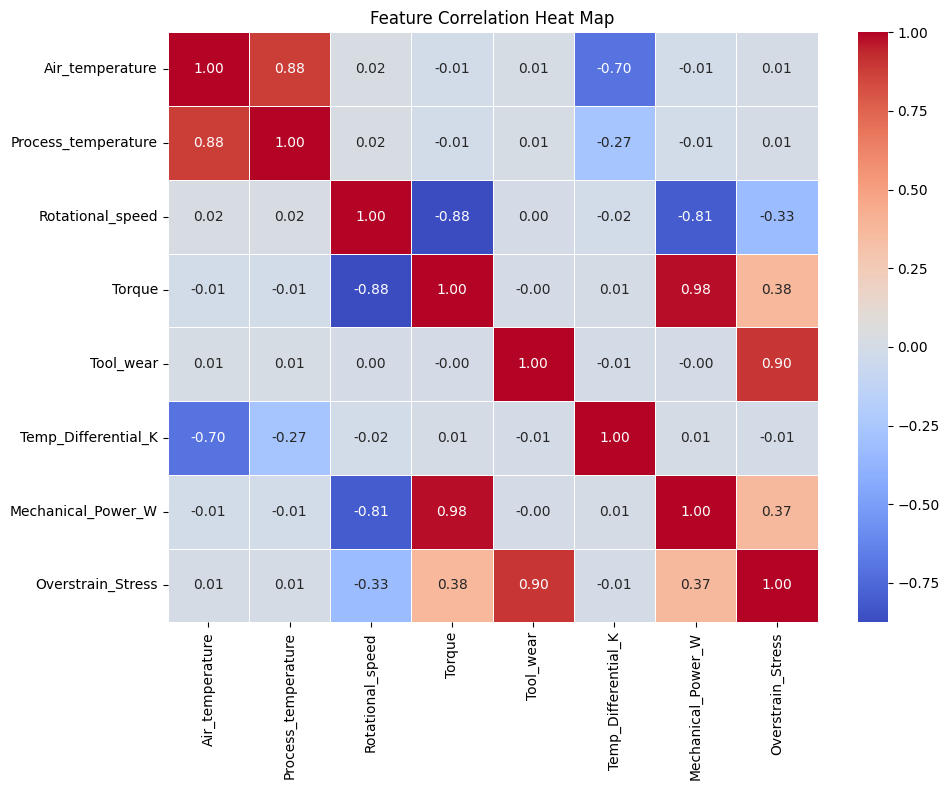

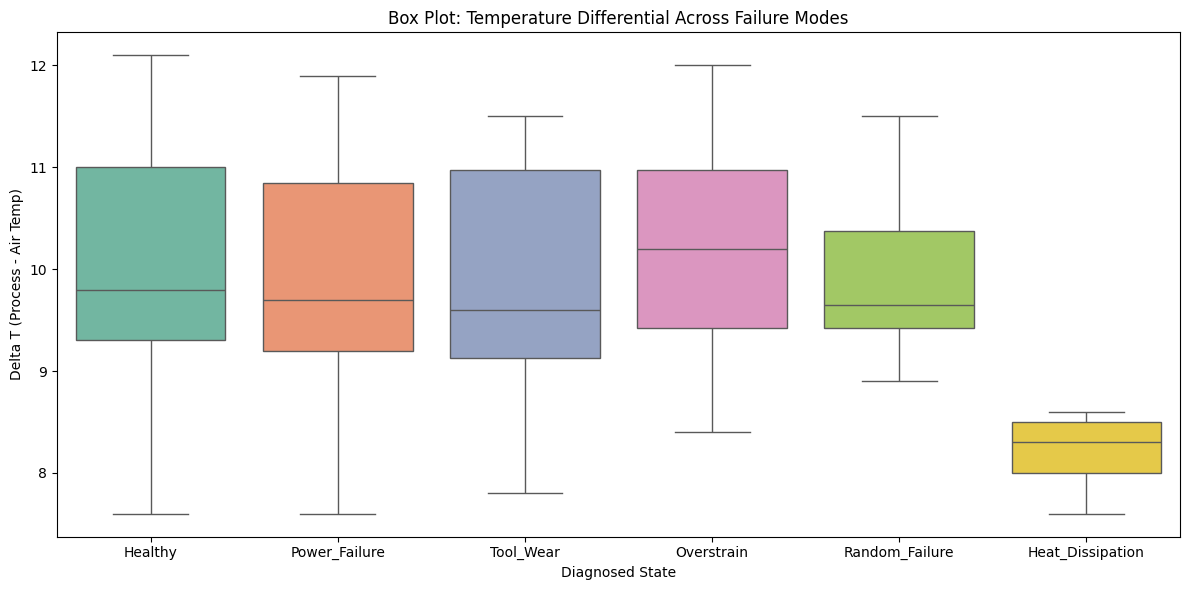


Preparing and balancing data for the AI...
Dataset successfully split! Training records: 8000 | Testing records: 2000

Training Diagnostic XGBoost Model with performance tracking...

              MODEL TEST ACCURACY
Overall AI Accuracy on Unseen Test Data: 94.75%

                  precision    recall  f1-score   support

         Healthy       1.00      0.95      0.97      1930
Heat_Dissipation       0.92      1.00      0.96        23
      Overstrain       0.73      1.00      0.84        16
   Power_Failure       1.00      0.83      0.91        18
  Random_Failure       0.00      0.00      0.00         4
       Tool_Wear       0.10      0.44      0.16         9

        accuracy                           0.95      2000
       macro avg       0.62      0.70      0.64      2000
    weighted avg       0.99      0.95      0.97      2000



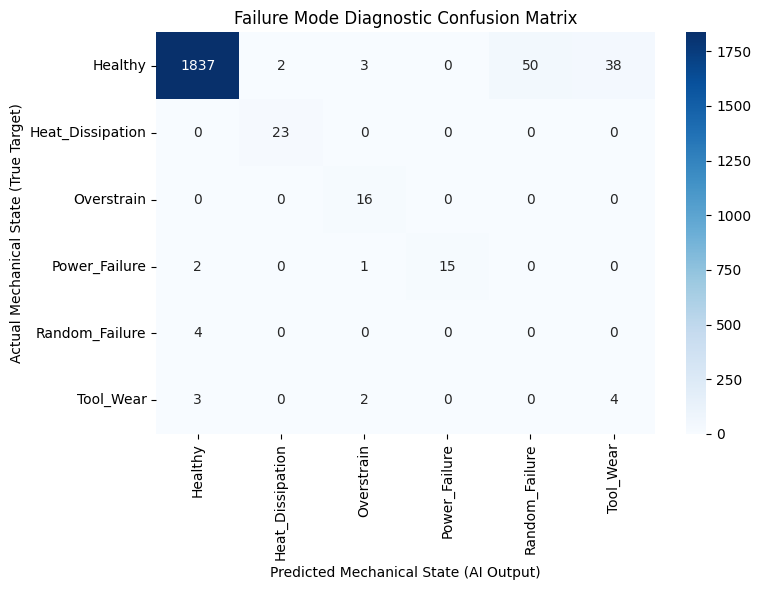

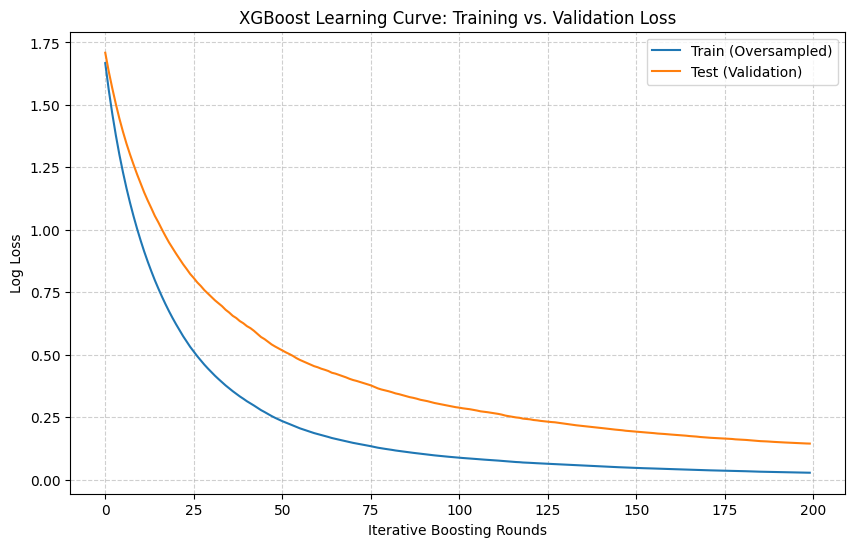


Generating SHAP Explanations...


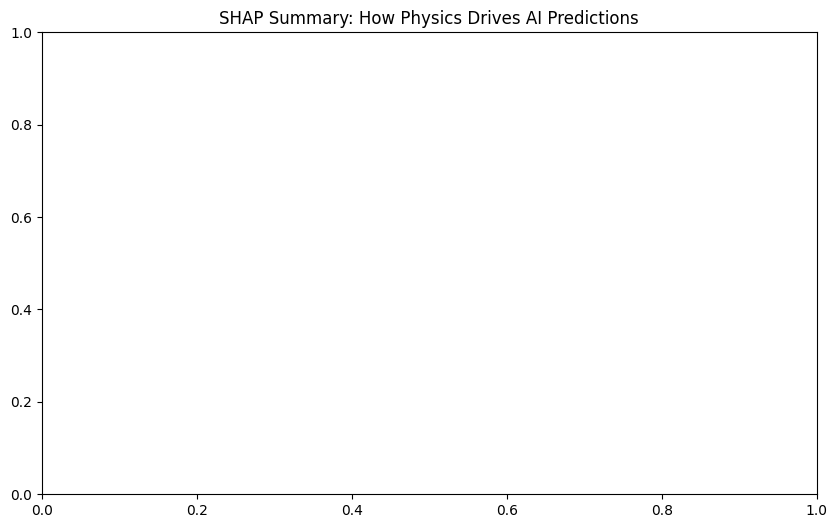

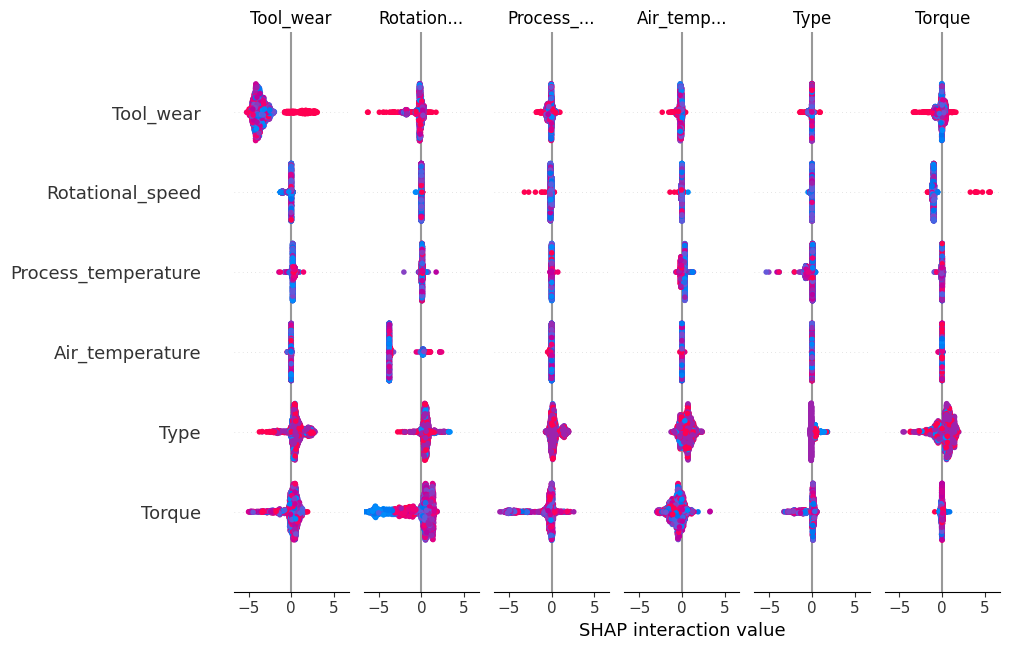


Loading Interactive Diagnostic Dashboard...


interactive(children=(Dropdown(description='Quality:', index=1, options=('L', 'M', 'H'), value='M'), FloatSlid…


           RANDOM FOREST TEST ACCURACY
Overall AI Accuracy on Unseen Test Data: 94.75%

                  precision    recall  f1-score   support

         Healthy       1.00      0.95      0.97      1930
Heat_Dissipation       0.92      1.00      0.96        23
      Overstrain       0.73      1.00      0.84        16
   Power_Failure       1.00      0.83      0.91        18
  Random_Failure       0.00      0.00      0.00         4
       Tool_Wear       0.10      0.44      0.16         9

        accuracy                           0.95      2000
       macro avg       0.62      0.70      0.64      2000
    weighted avg       0.99      0.95      0.97      2000



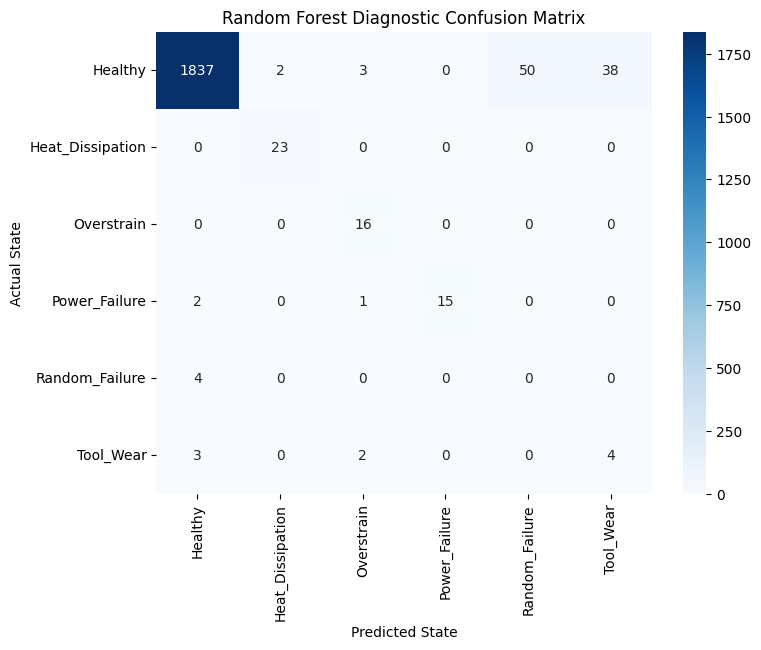


Generating SHAP Explanations...


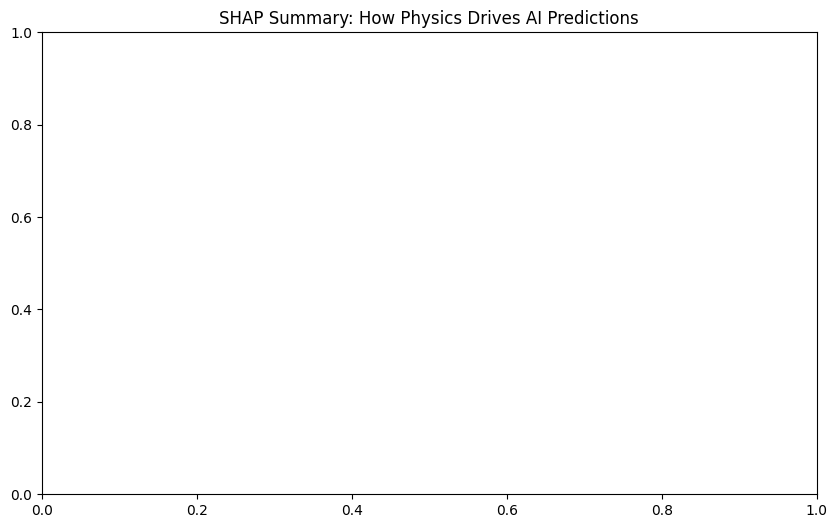

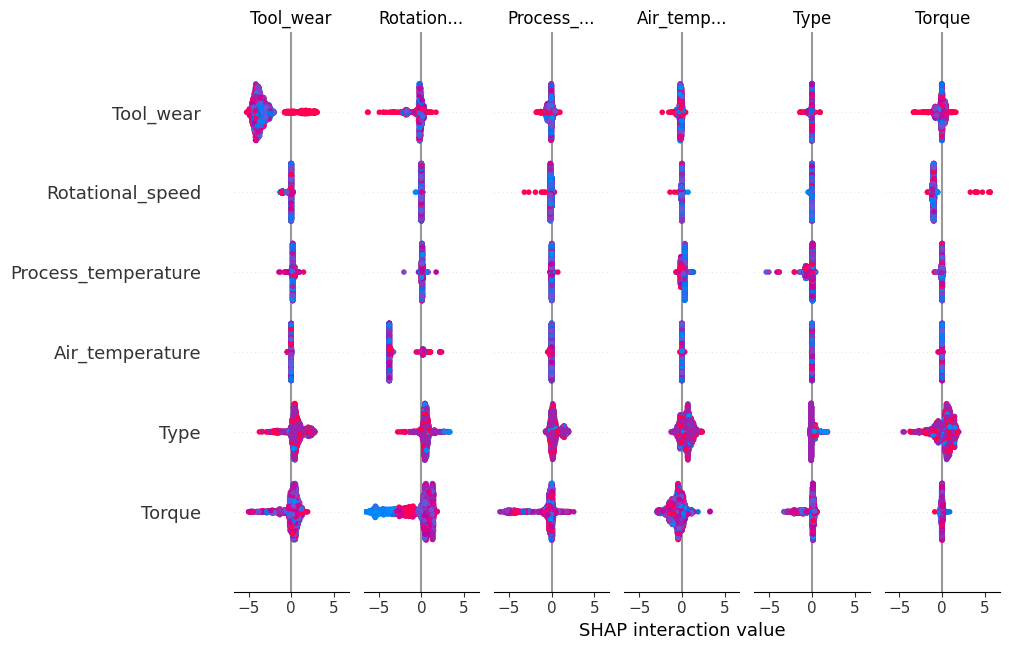


Loading Interactive Diagnostic Dashboard...


interactive(children=(Dropdown(description='Quality:', index=1, options=('L', 'M', 'H'), value='M'), FloatSlid…

In [10]:
# ==========================================
# 1. SETUP & DATA FETCHING
# ==========================================
# Install required libraries in Colab (Uncomment if running in a fresh environment)
# !pip install -q ucimlrepo shap xgboost imbalanced-learn ipywidgets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTENC
import xgboost as xgb
import shap
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore') # Hides warning messages during presentation

print("Fetching AI4I 2020 Predictive Maintenance Dataset from UCI...")
ai4i_2020 = fetch_ucirepo(id=601)

X = ai4i_2020.data.features
y = ai4i_2020.data.targets
df = pd.concat([X, y], axis=1)

# Clean column names (XGBoost does not allow brackets in feature names)
df.columns = df.columns.str.replace(' ', '_').str.replace(r'[\[\]<]', '', regex=True)

# ==========================================
# 2. PHYSICS-INFORMED FEATURE ENGINEERING
# ==========================================
print("Engineering Physics-Based Features...")

# A. Temperature Differential (Delta T)
df['Temp_Differential_K'] = df['Process_temperature'] - df['Air_temperature']

# B. Mechanical Power Output (Watts)
df['Mechanical_Power_W'] = df['Torque'] * (df['Rotational_speed'] * (2 * np.pi / 60))

# C. Overstrain Metric (Min * Nm)
df['Overstrain_Stress'] = df['Tool_wear'] * df['Torque']

# ==========================================
# 3. TARGET CLASSIFICATION
# ==========================================
conditions = [
    (df['TWF'] == 1), (df['HDF'] == 1), (df['PWF'] == 1),
    (df['OSF'] == 1), (df['RNF'] == 1)
]
choices = ['Tool_Wear', 'Heat_Dissipation', 'Power_Failure', 'Overstrain', 'Random_Failure']
df['Failure_Mode'] = np.select(conditions, choices, default='Healthy')

df = df.drop(columns=['Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA VISUALS)
# ==========================================
print("\nGenerating Pre-Modeling Data Visualizations (EDA)...")

# Heatmap: Feature Correlation
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heat Map')
plt.tight_layout()
plt.show()

# Box Plot: Physical Stress vs Failure Mode
plt.figure(figsize=(12, 6))
sns.boxplot(x='Failure_Mode', y='Temp_Differential_K', data=df, palette='Set2')
plt.title('Box Plot: Temperature Differential Across Failure Modes')
plt.xlabel('Diagnosed State')
plt.ylabel('Delta T (Process - Air Temp)')
plt.tight_layout()
plt.show()

# ==========================================
# 5. DATA PREPARATION & BALANCING (TRAIN/TEST SPLIT)
# ==========================================
print("\nPreparing and balancing data for the AI...")

le_type = LabelEncoder()
df['Type'] = le_type.fit_transform(df['Type'])

le_target = LabelEncoder()
df['Failure_Mode_Encoded'] = le_target.fit_transform(df['Failure_Mode'])

X_model = df.drop(columns=['Failure_Mode', 'Failure_Mode_Encoded'])
y_model = df['Failure_Mode_Encoded']

# ---> SPLITTING THE DATASET HERE <---
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

print(f"Dataset successfully split! Training records: {len(X_train)} | Testing records: {len(X_test)}")

smote = SMOTENC(categorical_features=[X_train.columns.get_loc('Type')], random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ==========================================
# ==========================================
# ==========================================
# 1. SETUP & DATA FETCHING
# ==========================================
# Install required libraries in Colab (Uncomment if running in a fresh environment)
# !pip install -q ucimlrepo shap xgboost imbalanced-learn ipywidgets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTENC
import xgboost as xgb
import shap
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore') # Hides warning messages during presentation

print("Fetching AI4I 2020 Predictive Maintenance Dataset from UCI...")
ai4i_2020 = fetch_ucirepo(id=601)

X = ai4i_2020.data.features
y = ai4i_2020.data.targets
df = pd.concat([X, y], axis=1)

# Clean column names (XGBoost does not allow brackets in feature names)
df.columns = df.columns.str.replace(' ', '_').str.replace(r'[\[\]<]', '', regex=True)

# ==========================================
# 2. PHYSICS-INFORMED FEATURE ENGINEERING
# ==========================================
print("Engineering Physics-Based Features...")

# A. Temperature Differential (Delta T)
df['Temp_Differential_K'] = df['Process_temperature'] - df['Air_temperature']

# B. Mechanical Power Output (Watts)
df['Mechanical_Power_W'] = df['Torque'] * (df['Rotational_speed'] * (2 * np.pi / 60))

# C. Overstrain Metric (Min * Nm)
df['Overstrain_Stress'] = df['Tool_wear'] * df['Torque']

# ==========================================
# 3. TARGET CLASSIFICATION
# ==========================================
conditions = [
    (df['TWF'] == 1), (df['HDF'] == 1), (df['PWF'] == 1),
    (df['OSF'] == 1), (df['RNF'] == 1)
]
choices = ['Tool_Wear', 'Heat_Dissipation', 'Power_Failure', 'Overstrain', 'Random_Failure']
df['Failure_Mode'] = np.select(conditions, choices, default='Healthy')

df = df.drop(columns=['Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA VISUALS)
# ==========================================
print("\nGenerating Pre-Modeling Data Visualizations (EDA)...")

# Heatmap: Feature Correlation
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heat Map')
plt.tight_layout()
plt.show()

# Box Plot: Physical Stress vs Failure Mode
plt.figure(figsize=(12, 6))
sns.boxplot(x='Failure_Mode', y='Temp_Differential_K', data=df, palette='Set2')
plt.title('Box Plot: Temperature Differential Across Failure Modes')
plt.xlabel('Diagnosed State')
plt.ylabel('Delta T (Process - Air Temp)')
plt.tight_layout()
plt.show()

# ==========================================
# 5. DATA PREPARATION & BALANCING (TRAIN/TEST SPLIT)
# ==========================================
print("\nPreparing and balancing data for the AI...")

le_type = LabelEncoder()
df['Type'] = le_type.fit_transform(df['Type'])

le_target = LabelEncoder()
df['Failure_Mode_Encoded'] = le_target.fit_transform(df['Failure_Mode'])

X_model = df.drop(columns=['Failure_Mode', 'Failure_Mode_Encoded'])
y_model = df['Failure_Mode_Encoded']

# ---> SPLITTING THE DATASET HERE <---
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

print(f"Dataset successfully split! Training records: {len(X_train)} | Testing records: {len(X_test)}")

smote = SMOTENC(categorical_features=[X_train.columns.get_loc('Type')], random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ==========================================
# ==========================================
# 6. MODEL TRAINING (XGBoost)
# ==========================================
print("\nTraining Diagnostic XGBoost Model with performance tracking...")

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le_target.classes_),
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric=["mlogloss"]  # Track multi-class log loss
)

# Define the evaluation set to monitor training vs validation performance
eval_set = [(X_train_res, y_train_res), (X_test, y_test)]

# Fit the model
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=eval_set,
    verbose=False  # Set to True if you want to see the raw logs per epoch
)

y_pred = xgb_model.predict(X_test)
# ==========================================
# 7. EVALUATION & CONFUSION MATRIX (ACCURACY OUTPUT)
# ==========================================
print("\n" + "="*50)
print("              MODEL TEST ACCURACY")
print("="*50)

# ---> CHECKING AND OUTPUTTING ACCURACY HERE <---
acc = accuracy_score(y_test, y_pred)
print(f"Overall AI Accuracy on Unseen Test Data: {acc * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Failure Mode Diagnostic Confusion Matrix')
plt.xlabel('Predicted Mechanical State (AI Output)')
plt.ylabel('Actual Mechanical State (True Target)')
plt.tight_layout()
plt.show()

# ==========================================
# 7.1 LEARNING & PREDICTING CURVES
# ==========================================
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train (Oversampled)')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Test (Validation)')

plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Iterative Boosting Rounds')
plt.title('XGBoost Learning Curve: Training vs. Validation Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==========================================
# 8. EXPLAINABLE AI (XAI)
# ==========================================
print("\nGenerating SHAP Explanations...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title('SHAP Summary: How Physics Drives AI Predictions')
shap.summary_plot(shap_values, X_test, class_names=le_target.classes_, show=False)
plt.tight_layout()
plt.show()

# ==========================================
# 9. INTERACTIVE LIVE DASHBOARD
# ==========================================
print("\nLoading Interactive Diagnostic Dashboard...")

def interactive_diagnosis(Type, Air_Temp_K, Process_Temp_K, RPM, Torque_Nm, Tool_Wear_min):
    delta_t = Process_Temp_K - Air_Temp_K
    power_w = Torque_Nm * (RPM * (2 * np.pi / 60))
    overstrain = Tool_Wear_min * Torque_Nm

    live_input = pd.DataFrame({
        'Type': [Type],
        'Air_temperature': [Air_Temp_K],
        'Process_temperature': [Process_Temp_K],
        'Rotational_speed': [RPM],
        'Torque': [Torque_Nm],
        'Tool_wear': [Tool_Wear_min],
        'Temp_Differential_K': [delta_t],
        'Mechanical_Power_W': [power_w],
        'Overstrain_Stress': [overstrain]
    })

    live_input['Type'] = le_type.transform(live_input['Type'])
    live_input = live_input[X_train.columns]

    probabilities = xgb_model.predict_proba(live_input)[0]
    predicted_index = np.argmax(probabilities)
    predicted_label = le_target.inverse_transform([predicted_index])[0]

    clear_output(wait=True)
    print("=" * 60)
    print(f"                🔴 LIVE SYSTEM DIAGNOSIS 🔴")
    print("=" * 60)

    if predicted_label == 'Healthy':
        print(f"\nSTATUS: ✅ {predicted_label.upper()}")
    else:
        print(f"\nSTATUS: ⚠️ CRITICAL FAULT IMMINENT -> {predicted_label.replace('_', ' ').upper()}")

    print("\n--- Failure Mode Probabilities ---")
    for label, prob in zip(le_target.classes_, probabilities):
        bar_length = int(prob * 20)
        bar = "█" * bar_length + "-" * (20 - bar_length)
        print(f"{label.ljust(18)} | {bar} | {prob*100:>5.1f}%")

    print("\n--- Live Physics Telemetry ---")
    print(f"🌡️ Delta T (Heat Stress) : {delta_t:>7.1f} K")
    print(f"⚙️ Overstrain Stress     : {overstrain:>7.1f} Min*Nm")
    print(f"⚡ Kinetic Power Output  : {power_w:>7.1f} Watts")
    print("=" * 60)

ui = widgets.interactive(
    interactive_diagnosis,
    Type=widgets.Dropdown(options=['L', 'M', 'H'], value='M', description='Quality:'),
    Air_Temp_K=widgets.FloatSlider(value=300.0, min=290.0, max=310.0, step=0.1, description='Air Temp(K):', layout={'width': '500px'}),
    Process_Temp_K=widgets.FloatSlider(value=310.0, min=295.0, max=330.0, step=0.1, description='Proc Temp(K):', layout={'width': '500px'}),
    RPM=widgets.IntSlider(value=1500, min=1000, max=2880, step=10, description='Speed(RPM):', layout={'width': '500px'}),
    Torque_Nm=widgets.FloatSlider(value=40.0, min=10.0, max=80.0, step=0.5, description='Torque(Nm):', layout={'width': '500px'}),
    Tool_Wear_min=widgets.IntSlider(value=50, min=0, max=260, step=1, description='Wear(mins):', layout={'width': '500px'})
)

display(ui)
# ==========================================
# 7. EVALUATION & CONFUSION MATRIX
# ==========================================
print("\n" + "="*50)
print(f"           {winner_name.upper()} TEST ACCURACY")
print("="*50)

acc = accuracy_score(y_test, y_pred)
print(f"Overall AI Accuracy on Unseen Test Data: {acc * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'{winner_name} Diagnostic Confusion Matrix')
plt.xlabel('Predicted State')
plt.ylabel('Actual State')
plt.show()

# ==========================================
# 7.1 LEARNING & PREDICTING CURVES
# ==========================================
if winner_name == "XGBoost":
    results = final_model.evals_result()
    epochs = len(results['validation_0']['mlogloss'])
    x_axis = range(0, epochs)

    plt.figure(figsize=(10, 6))
    plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train (Oversampled)')
    plt.plot(x_axis, results['validation_1']['mlogloss'], label='Test (Validation)')
    plt.legend()
    plt.ylabel('Log Loss')
    plt.xlabel('Boosting Rounds')
    plt.title(f'{winner_name} Learning Progress')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# ==========================================
# 8. EXPLAINABLE AI (XAI)
# ==========================================
print("\nGenerating SHAP Explanations...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title('SHAP Summary: How Physics Drives AI Predictions')
shap.summary_plot(shap_values, X_test, class_names=le_target.classes_, show=False)
plt.tight_layout()
plt.show()

# ==========================================
# 9. INTERACTIVE LIVE DASHBOARD
# ==========================================
print("\nLoading Interactive Diagnostic Dashboard...")

def interactive_diagnosis(Type, Air_Temp_K, Process_Temp_K, RPM, Torque_Nm, Tool_Wear_min):
    delta_t = Process_Temp_K - Air_Temp_K
    power_w = Torque_Nm * (RPM * (2 * np.pi / 60))
    overstrain = Tool_Wear_min * Torque_Nm

    live_input = pd.DataFrame({
        'Type': [Type],
        'Air_temperature': [Air_Temp_K],
        'Process_temperature': [Process_Temp_K],
        'Rotational_speed': [RPM],
        'Torque': [Torque_Nm],
        'Tool_wear': [Tool_Wear_min],
        'Temp_Differential_K': [delta_t],
        'Mechanical_Power_W': [power_w],
        'Overstrain_Stress': [overstrain]
    })

    live_input['Type'] = le_type.transform(live_input['Type'])
    live_input = live_input[X_train.columns]

    probabilities = xgb_model.predict_proba(live_input)[0]
    predicted_index = np.argmax(probabilities)
    predicted_label = le_target.inverse_transform([predicted_index])[0]

    clear_output(wait=True)
    print("=" * 60)
    print(f"                🔴 LIVE SYSTEM DIAGNOSIS 🔴")
    print("=" * 60)

    if predicted_label == 'Healthy':
        print(f"\nSTATUS: ✅ {predicted_label.upper()}")
    else:
        print(f"\nSTATUS: ⚠️ CRITICAL FAULT IMMINENT -> {predicted_label.replace('_', ' ').upper()}")

    print("\n--- Failure Mode Probabilities ---")
    for label, prob in zip(le_target.classes_, probabilities):
        bar_length = int(prob * 20)
        bar = "█" * bar_length + "-" * (20 - bar_length)
        print(f"{label.ljust(18)} | {bar} | {prob*100:>5.1f}%")

    print("\n--- Live Physics Telemetry ---")
    print(f"🌡️ Delta T (Heat Stress) : {delta_t:>7.1f} K")
    print(f"⚙️ Overstrain Stress     : {overstrain:>7.1f} Min*Nm")
    print(f"⚡ Kinetic Power Output  : {power_w:>7.1f} Watts")
    print("=" * 60)

ui = widgets.interactive(
    interactive_diagnosis,
    Type=widgets.Dropdown(options=['L', 'M', 'H'], value='M', description='Quality:'),
    Air_Temp_K=widgets.FloatSlider(value=300.0, min=290.0, max=310.0, step=0.1, description='Air Temp(K):', layout={'width': '500px'}),
    Process_Temp_K=widgets.FloatSlider(value=310.0, min=295.0, max=330.0, step=0.1, description='Proc Temp(K):', layout={'width': '500px'}),
    RPM=widgets.IntSlider(value=1500, min=1000, max=2880, step=10, description='Speed(RPM):', layout={'width': '500px'}),
    Torque_Nm=widgets.FloatSlider(value=40.0, min=10.0, max=80.0, step=0.5, description='Torque(Nm):', layout={'width': '500px'}),
    Tool_Wear_min=widgets.IntSlider(value=50, min=0, max=260, step=1, description='Wear(mins):', layout={'width': '500px'})
)

display(ui)